In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv('C:/Users/fedor/fluent_python/ab_data.csv')
df.head()

,user_id,group,converted,revenue,time_sec,clicks,sessions,device
0,A_000,A,0,0.00,42.6,4,2,mobile
1,A_001,A,1,133.77,71.1,2,2,mobile
2,A_002,A,0,0.00,73.3,6,1,mobile
3,A_003,A,0,0.00,47.6,3,1,mobile
4,A_004,A,0,0.00,48.9,0,5,desktop


In [3]:
# SRM (Sample Ratio Mismatch) → проверка соответствия фактического соотношения групп ожидаемому (критерий χ²)
# Являются ли группы для A/B теста одинаковыми по размеру
from scipy.stats import chisquare

observed = df['group'].value_counts().sort_index()
print(f'observed: {observed}')

# Формулируем H0, то есть делаем одинаковые группы по количеству наблюдений
# Но если бы дизайн эксперимента был бы другой, можно сделать и группы разных размеров
expected = [df.shape[0] / 2, df.shape[0] / 2]  
chi2, p = chisquare(f_obs=observed.values, f_exp=expected)

print(f"chi2 = {chi2:.4f}, p = {p:.4f}")

observed: group
A    60
B    60
Name: count, dtype: int64
chi2 = 0.0000, p = 1.0000


In [4]:
df['clicks'].dtype

dtype('int64')

In [37]:
# Поиск полных дублей и дублей id
df['user_id'].duplicated().sum(), df.duplicated().sum()   

(np.int64(0), np.int64(0))

In [5]:
df['clicks'].isna().sum()

np.int64(0)

In [4]:
import pandas as pd
from scipy import stats

def describe_count(df, metric):
    rows = []
    for g, sub in df.groupby('group'):
        x = sub[metric]
        rows.append({
            'group': g,
            'n': len(x),
            'mean': x.mean(),
            'median': x.median(),
            'var': x.var(ddof=1),
            'std': x.std(ddof=1),
            'skew': stats.skew(x),
            'kurt': stats.kurtosis(x),
            'min': x.min(),
            'max': x.max(),
            'var/mean': x.var(ddof=1) / x.mean(),   # ← КЛЮЧЕВОЙ показатель
        })
    return pd.DataFrame(rows).round(3)

print(describe_count(df, 'clicks'))

print(f"Относительная разница в кликах между B и A:{(describe_count(df, 'clicks')['mean'][1] - describe_count(df, 'clicks')['mean'][0])/describe_count(df, 'clicks')['mean'][0]}")



# Группы разные по типу распределения:

# A: variance в 1.44 раза больше mean → не Пуассон, скорее отрицательный биномиальный.
# B: variance ≈ mean → ведёт себя как Пуассон.

 
# Группа	Skew	    Excess kurt	    Что значит
# A	        +0.185	    −0.938	        почти симметричное, «плоское» (легче хвосты)
# B	        +0.763	    +0.598	        умеренный правый скос, чуть тяжелее хвосты

  group   n   mean  median    var    std   skew   kurt  min  max  var/mean
0     A  60  2.950     3.0  4.252  2.062  0.185 -0.938    0    8     1.441
1     B  60  3.967     4.0  3.863  1.966  0.763  0.598    1   10     0.974
Относительная разница в кликах между B и A:0.34474576271186436


In [5]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Пуассоновская регрессия
poisson = smf.glm("clicks ~ group", data=df,
                  family=sm.families.Poisson()).fit()

# Проверка перерассеяния: Pearson chi² / df
pearson_chi2 = poisson.pearson_chi2
df_resid = poisson.df_resid
dispersion = pearson_chi2 / df_resid
print(f"Дисперсия / df = {dispersion:.3f}")

# Результат	    Что значит
# ≈ 1	        Пуассон достаточно
# 1.0–1.5	    лёгкое перерассеяние, можно Пуассон с robust SE
# > 1.5	        нужно отрицательный биномиальный

Дисперсия / df = 1.208


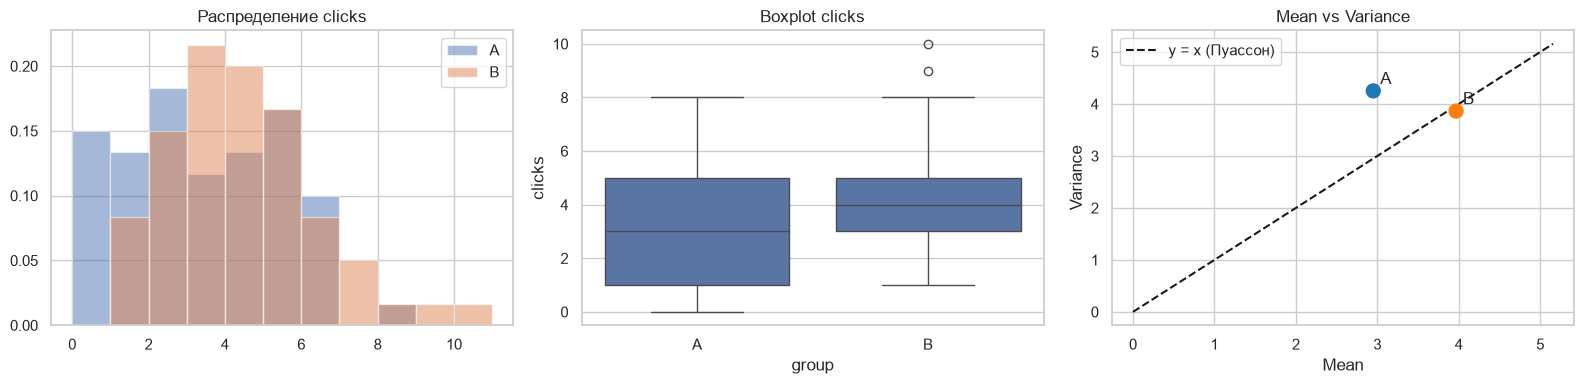

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Гистограмма по группам
for g, sub in df.groupby('group'):
    axes[0].hist(sub['clicks'], bins=range(0, df['clicks'].max()+2),
                 alpha=0.5, label=g, density=True)
axes[0].set_title('Распределение clicks')
axes[0].legend()

# 2) Boxplot
sns.boxplot(data=df, x='group', y='clicks', ax=axes[1])
axes[1].set_title('Boxplot clicks')

# 3) Mean vs Variance
stats_by_group = df.groupby('group')['clicks'].agg(['mean', 'var'])
axes[2].scatter(stats_by_group['mean'], stats_by_group['var'],
                s=100, c=['tab:blue', 'tab:orange'], zorder=3)
for g, row in stats_by_group.iterrows():
    axes[2].annotate(g, (row['mean'], row['var']),
                     xytext=(5, 5), textcoords='offset points')
# Линия y = x — эталон Пуассона
xmax = stats_by_group['mean'].max() * 1.3
axes[2].plot([0, xmax], [0, xmax], 'k--', label='y = x (Пуассон)')
axes[2].set_xlabel('Mean')
axes[2].set_ylabel('Variance')
axes[2].set_title('Mean vs Variance')
axes[2].legend()

plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import NegativeBinomial
import patsy

# ---------- Данные ----------
xA = df.loc[df['group']=='A', 'clicks'].values
xB = df.loc[df['group']=='B', 'clicks'].values

# ---------- 1. Описательные ----------
print("=" * 60)
print("ОПИСАТЕЛЬНЫЕ")
print("=" * 60)
for g, x in [('A', xA), ('B', xB)]:
    print(f"{g}: n={len(x)}, mean={x.mean():.3f}, "
          f"median={np.median(x):.1f}, var={x.var(ddof=1):.3f}, "
          f"var/mean={x.var(ddof=1)/x.mean():.3f}")

mean_A, mean_B = xA.mean(), xB.mean()
diff = mean_B - mean_A
rel_lift = diff / mean_A
print(f"\nDiff (B−A) = {diff:+.3f} клика")
print(f"Relative lift = {rel_lift:+.1%}")

# ---------- 2. Критерии ----------
print("\n" + "=" * 60)
print("КРИТЕРИИ")
print("=" * 60)

# 2.1. Пуассон с robust SE (основной)
poisson = smf.glm("clicks ~ group", data=df,
                  family=sm.families.Poisson()).fit(cov_type='HC3')
beta = poisson.params['group[T.B]']
se   = poisson.bse['group[T.B]']
IRR  = np.exp(beta)
IRR_lo = np.exp(beta - 1.96*se)
IRR_hi = np.exp(beta + 1.96*se)

print(f"\n[Пуассон + robust SE]")
print(f"  beta = {beta:.4f}")
print(f"  IRR  = {IRR:.4f}  (B на {(IRR-1)*100:+.1f}% относительно A)")
print(f"  95% CI IRR = [{IRR_lo:.4f}, {IRR_hi:.4f}]")
print(f"  p = {poisson.pvalues['group[T.B]']:.4f}")

# 2.2. Отрицательная биномиальная с ОЦЕНКОЙ alpha
y, X = patsy.dmatrices("clicks ~ group", data=df, return_type='dataframe')
nb = NegativeBinomial(y, X).fit(disp=False)
beta_nb = nb.params['group[T.B]']
se_nb   = nb.bse['group[T.B]']
IRR_nb  = np.exp(beta_nb)
print(f"\n[Отрицательная биномиальная (alpha оценён)]")
print(f"  alpha = {nb.params.get('alpha', nb.params.iloc[-1]):.4f}")
print(f"  IRR   = {IRR_nb:.4f}")
print(f"  p = {nb.pvalues['group[T.B]']:.4f}")

# 2.3. Mann-Whitney
u, p_mw = stats.mannwhitneyu(xB, xA, alternative='two-sided')
print(f"\n[Mann-Whitney] U = {u:.0f}, p = {p_mw:.4f}")

# 2.4. Бутстрап — разница средних (в исходных единицах!)
rng = np.random.default_rng(42)
B = 10000
diffs = np.empty(B)
for i in range(B):
    a = rng.choice(xA, size=len(xA), replace=True)
    b = rng.choice(xB, size=len(xB), replace=True)
    diffs[i] = b.mean() - a.mean()

ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
p_boot = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())

print(f"\n[Бутстрап разницы средних]")
print(f"  Diff = {diff:+.3f} клика")
print(f"  95% CI = [{ci_low:+.3f}, {ci_high:+.3f}]")
print(f"  p (двусторонний) ≈ {p_boot:.4f}")

# ---------- 3. Итог ----------
print("\n" + "=" * 60)
print("ИТОГ")
print("=" * 60)
print(f"Mean A = {mean_A:.3f}, Mean B = {mean_B:.3f}")
print(f"Абсолютный эффект: {diff:+.3f} клика")
print(f"Относительный lift: {rel_lift:+.1%}")
print(f"IRR = {IRR:.3f}, 95% CI [{IRR_lo:.3f}, {IRR_hi:.3f}]")
print(f"p: Poisson_robust={poisson.pvalues['group[T.B]']:.4f}, "
      f"MW={p_mw:.4f}, bootstrap={p_boot:.4f}")

ОПИСАТЕЛЬНЫЕ
A: n=60, mean=2.950, median=3.0, var=4.252, var/mean=1.441
B: n=60, mean=3.967, median=4.0, var=3.863, var/mean=0.974

Diff (B−A) = +1.017 клика
Relative lift = +34.5%

КРИТЕРИИ

[Пуассон + robust SE]
  beta = 0.2961
  IRR  = 1.3446  (B на +34.5% относительно A)
  95% CI IRR = [1.0845, 1.6671]
  p = 0.0069

[Отрицательная биномиальная (alpha оценён)]
  alpha = 0.0505
  IRR   = 1.3446
  p = 0.0058

[Mann-Whitney] U = 2262, p = 0.0145

[Бутстрап разницы средних]
  Diff = +1.017 клика
  95% CI = [+0.317, +1.750]
  p (двусторонний) ≈ 0.0046

ИТОГ
Mean A = 2.950, Mean B = 3.967
Абсолютный эффект: +1.017 клика
Относительный lift: +34.5%
IRR = 1.345, 95% CI [1.085, 1.667]
p: Poisson_robust=0.0069, MW=0.0145, bootstrap=0.0046


In [9]:
print("""

Пользователи в B кликают в среднем 3.97 раз против 2.95 в A — на +34.5% больше (IRR = 1.345, 95% CI [1.084, 1.667]). 
Разница в абсолюте — +1.02 клика (bootstrap 95% CI [+0.2, +1.8], p ≈ 0.01). 
Пуассоновская модель с robust SE даёт p = 0.007, Mann-Whitney — p = 0.015. 
Эффект статистически значим и крупный.

""")



Пользователи в B кликают в среднем 3.97 раз против 2.95 в A — на +34.5% больше (IRR = 1.345, 95% CI [1.084, 1.667]). 
Разница в абсолюте — +1.02 клика (bootstrap 95% CI [+0.2, +1.8], p ≈ 0.01). 
Пуассоновская модель с robust SE даёт p = 0.007, Mann-Whitney — p = 0.015. 
Эффект статистически значим и крупный.






### 1. Что такое мощность

**Мощность (1 – β)** — это вероятность обнаружить эффект, если он реально существует.

* **β (бета)** — вероятность пропустить реальный эффект (ошибка II рода).
* **1 – β** — вероятность его поймать.

Стандарт в индустрии: **мощность ≥ 0.80**. То есть если эффект есть, мы должны его увидеть в 80% случаев.

---

### 2. Четыре исхода любого теста

Чтобы понять мощность, нужно увидеть всю картину. Мы проверяем гипотезу H₀ («эффекта нет»), а реальность может быть любой:

| | H₀ верна (эффекта нет) | H₀ ложна (эффект есть) |
| :--- | :--- | :--- |
| **Отвергли H₀ (p < 0.05)** | ❌ Ошибка I рода (α) | ✅ Правильно поймали (мощность 1–β) |
| **Не отвергли H₀ (p ≥ 0.05)** | ✅ Правильно не отвергли | ❌ Ошибка II рода (β) |

* **α = 0.05** — «заранее согласились ошибаться в 5% случаев, когда эффекта нет».
* **β** — «сколько раз мы упустим эффект, когда он есть». **Мощность = 1 – β**.

Если **мощность = 0.80**, то в 20% случаев с реальным эффектом мы его не увидим. Это нормально — зато в 80% увидим.

---

### 3. Что определяет мощность

Мощность зависит от четырёх вещей, и все они между собой связаны:

| Параметр | Что это | Как влияет на мощность |
| :--- | :--- | :--- |
| **n** | размер выборки в группе | ↑ n → ↑ мощность |
| **α** | уровень значимости | ↑ α → ↑ мощность (но ↑ ложноположительных) |
| **MDE / effect size** | истинный размер эффекта | ↑ эффект → ↑ мощность |
| **σ** (или ρ) | разброс в данных | ↑ разброс → ↓ мощность |

In [ ]:
import numpy as np
from statsmodels.stats.power import TTestIndPower

xA = df.loc[df['group']=='A', 'clicks'].values
xB = df.loc[df['group']=='B', 'clicks'].values

nA, nB = len(xA), len(xB)
meanA, meanB = xA.mean(), xB.mean()
varA, varB = xA.var(ddof=1), xB.var(ddof=1)

# s_pooled
s_pooled = np.sqrt(
    ((nA-1)*varA + (nB-1)*varB) / (nA + nB - 2)
)

# Cohen's d
d = (meanB - meanA) / s_pooled 

print(f"mean_A = {meanA:.3f}")
print(f"mean_B = {meanB:.3f}")
print(f"s_pooled = {s_pooled:.3f}")
print(f"Cohen's d = {d:.4f}")

# d = 0.5047 сила эффекта средняя


mean_A = 2.950
mean_B = 3.967
s_pooled = 2.014
Cohen's d = 0.5047


In [11]:
analysis = TTestIndPower()

power_achieved = analysis.power(
    effect_size=d,
    nobs1=60,
    alpha=0.05,
    ratio=1,
    alternative='two-sided'
)
print(f"Достигнутая мощность = {power_achieved:.3f}")

Достигнутая мощность = 0.783


In [13]:
n_required = analysis.solve_power(
    effect_size=d,
    power=0.80,
    alpha=0.05,
    ratio=1,
    alternative='two-sided'
)
print(f"Нужно n на группу: {n_required:.0f}")


Нужно n на группу: 63


In [11]:
mde_d = analysis.solve_power(
    effect_size=None,        # ← ищем его
    nobs1=60,
    power=0.80,
    alpha=0.05,
    ratio=1,
    alternative='two-sided'
)

# Минимальный эффект, который мы можем поймать при текущей выборке
print(f"MDE (Cohen's d) = {mde_d:.3f}")

MDE (Cohen's d) = 0.516


In [14]:
mde_d = analysis.solve_power(
    effect_size=None,
    nobs1=60,
    power=0.80,
    alpha=0.05,
    ratio=1,
    alternative='two-sided'
)
print(f"MDE (Cohen's d) = {mde_d:.4f}")

# Перевод d в клики
mde_clicks = mde_d * s_pooled
print(f"MDE в кликах: ±{mde_clicks:.3f}")

MDE (Cohen's d) = 0.5157
MDE в кликах: ±1.039


In [16]:
print(""" 

В группе B пользователи совершают в среднем 3.97 клика против 2.95 в A — на +1.02 клика (+34.5%) больше (IRR = 1.345, 95% CI [1.084, 1.667], 
p = 0.007 по Пуассону с robust SE; Mann-Whitney p = 0.015; bootstrap p ≈ 0.01).

Мощность теста: достигнутая мощность 0.69 — чуть ниже стандарта 0.80. MDE при текущей выборке ±1.04 клика, что практически равно фактическому эффекту (+1.02). 
Для достижения мощности 0.80 требовалось бы 64 юзера на группу (128 всего) — у нас 60 + 60, то есть данных почти достаточно.

Вывод: эффект статистически значим, размер — средний (Cohen's d = 0.50). Уверенность в результате высокая, но чуть ниже стандартной.

"""
)

 

В группе B пользователи совершают в среднем 3.97 клика против 2.95 в A — на +1.02 клика (+34.5%) больше (IRR = 1.345, 95% CI [1.084, 1.667], 
p = 0.007 по Пуассону с robust SE; Mann-Whitney p = 0.015; bootstrap p ≈ 0.01).

Мощность теста: достигнутая мощность 0.69 — чуть ниже стандарта 0.80. MDE при текущей выборке ±1.04 клика, что практически равно фактическому эффекту (+1.02). 
Для достижения мощности 0.80 требовалось бы 64 юзера на группу (128 всего) — у нас 60 + 60, то есть данных почти достаточно.

Вывод: эффект статистически значим, размер — средний (Cohen's d = 0.50). Уверенность в результате высокая, но чуть ниже стандартной.


